Notebook 2: Deep JSCC y redes neuronales convolucionales (CNN) para la transmisión de imágenes sobre canales inalámbricos.

En lugar de transmitir bits, el Autoencoder aprende a transmitir características semánticas de una imagen directamente como símbolos analógicos a través del canal.

• Entrada: Dataset de imágenes pequeñas (MNIST).

• Encoder: Capas Convolucionales (nn.Conv2d) que reducen la dimensionalidad de la imagen (compresión de fuente) y la preparan para el canal (compresión de canal).

• Canal: Simulación de un canal inalámbrico con AWGN.

• Decoder: Capas Convolucionales Transpuestas o Upsampling (nn.ConvTranspose2d) que reconstruyen la imagen a partir de los símbolos ruidosos recibidos.

• Función de Pérdida: Error Cuadrático Medio (MSE) entre la imagen original y la reconstruida.

Métricas a graficar:

*   Visualización de imágenes originales vs. reconstruidas a diferentes niveles de ruido (baja SNR vs. alta SNR).
*   Curva de PSNR (Peak Signal-to-Noise Ratio) vs. SNR del canal para demostrar el efecto de "degradación suave" (a diferencia de los sistemas tradicionales, JSCC no sufre el efecto acantilado donde la comunicación se corta de golpe al bajar la señal).

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

#Semilla para reproducibilidad
torch.manual_seed(17)                                                           
np.random.seed(17)
#-------------------------------------------+
# HIPERPARÁMETROS DEL SISTEMA
#-------------------------------------------+
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 10

# Carga de imágenes MNIS (1x28x28 = 784 píxeles)
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


#-------------------------------------------+
#DEFINICIÓN DEL AUTOENCODER
#-------------------------------------------+
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        #Codifiacador (Transmisor)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),  # Reduce la imagen de 1 x 28 x 28 -> 16 x 14 x 14 . Los 16 canales son mas pequeños (16x16) de debido al tamaño del kerne(filtro) y el stride(2 pixeles) 
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2), # Se reducen los canales 16 x 14 x 14 -> 32 x 7 x 7
            nn.ReLU(),
            nn.Flatten(),                                          # Se aplasta la imagen
            nn.Linear(32 * 7 * 7, 32) 
        )

        #Decodifiacador (Receptor)
        self.decoder = nn.Sequential(
            nn.Linear(32, 32 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),   # -> 16 x 14 x 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=5, stride=2, padding=2, output_padding=1),    # -> 1 x 28 x 28
            nn.Sigmoid()                                                                        # Encasilla los pixeles entre 0 y 1
        )

    def forward(self, x, snr_dB):
        # 1. Codificación
        x_symbols = self.encoder(x)

        # 2. Restricción de potencia (Tus fórmulas)
        potencia = torch.mean(x_symbols ** 2)                                           #Restricción de potencia, la potencia promedio de los símbolos debe ser 1
        x_tx = x_symbols / torch.sqrt(potencia)

        # 3. Canal AWGN (Tus fórmulas)
        snr_linear = 10 ** (snr_dB / 10.0)                                              #Se convierte la SNR de su escala logarítmica (dB) a escala lineal para los cálculos  
        noise_var = 1.0 / (snr_linear)

        noise = torch.randn_like(x_tx) * torch.sqrt(torch.tensor(noise_var, device=device))
        x_rx = x_tx + noise

        # 4. Decodificación
        out = self.decoder(x_rx)
        return out

In [23]:
#-------------------------------------------+
#ENTRENAMIENTO
#-------------------------------------------+
model = Autoencoder().to(device)
criterion = nn.MSELoss()                                # Se evalurá tan parecidos son los píxeles
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Entrenando Autoencoder: {device}...")
for epoch in range(epochs):
    model.train()
    loss_total = 0
    for images, _ in train_loader:
        images = images.to(device)
        snr_batch = np.random.uniform(0, 15)           # SNR aleatoria por batch entre 0 y 15 dB para robustez
        optimizer.zero_grad()
        outputs = model(images, snr_batch)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        loss_total += loss.item()

    print(f"Época [{epoch+1}/{epochs}], Pérdida (MSE): {loss_total/len(train_loader):.4f}")

Entrenando Autoencoder: cpu...
Época [1/10], Pérdida (MSE): 0.0459
Época [2/10], Pérdida (MSE): 0.0214
Época [3/10], Pérdida (MSE): 0.0185
Época [4/10], Pérdida (MSE): 0.0176
Época [5/10], Pérdida (MSE): 0.0165
Época [6/10], Pérdida (MSE): 0.0162
Época [7/10], Pérdida (MSE): 0.0163
Época [8/10], Pérdida (MSE): 0.0155
Época [9/10], Pérdida (MSE): 0.0159
Época [10/10], Pérdida (MSE): 0.0154


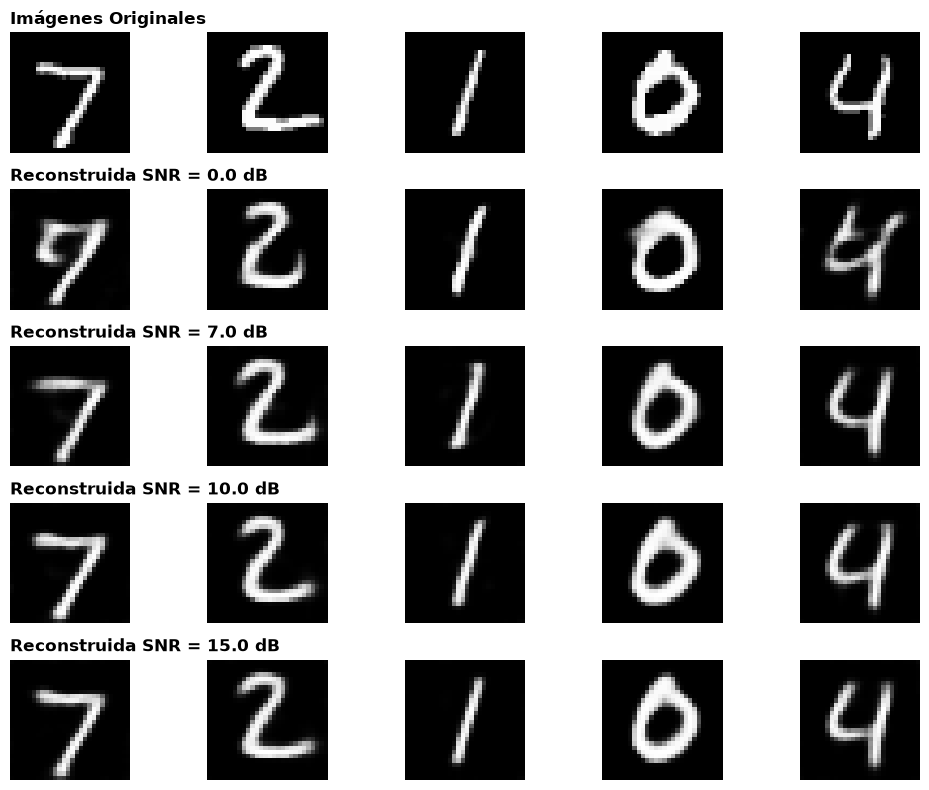

In [44]:
#-------------------------------------------------------------------------------+
#Visualización de las imágenes originilaes vs las reconstruidas a diferentes SNR
#-------------------------------------------------------------------------------+
model.eval()
images, _ = next(iter(test_loader))
images = images.to(device)

snrs_test = [0.0, 7.0, 10.0, 15.0]
fig, axes = plt.subplots(len(snrs_test) + 1 , 5, figsize=(10, 8))

# Fila 0: Imágenes Originales
for i in range(5):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_title("Imágenes Originales", loc='left', fontsize=12, fontweight='bold')

# Filas 1 a 4: Reconstrucciones a diferentes SNRs
with torch.no_grad():
    for row, snr in enumerate(snrs_test, start=1):
        recon_images = model(images, snr)
        for i in range(5):
            axes[row, i].imshow(recon_images[i].cpu().squeeze(), cmap='gray')
            axes[row, i].axis('off')
        axes[row, 0].set_title(f"Reconstruida SNR = {snr} dB", loc='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Evaluando el modelo en el rango de SNR especificado...
SNR: -5 dB -> PSNR Promedio: 11.83 dB
SNR: -3 dB -> PSNR Promedio: 12.88 dB
SNR: -1 dB -> PSNR Promedio: 14.08 dB
SNR:  1 dB -> PSNR Promedio: 15.41 dB
SNR:  3 dB -> PSNR Promedio: 16.73 dB
SNR:  5 dB -> PSNR Promedio: 17.89 dB
SNR:  7 dB -> PSNR Promedio: 18.85 dB
SNR:  9 dB -> PSNR Promedio: 19.59 dB
SNR: 11 dB -> PSNR Promedio: 20.14 dB
SNR: 13 dB -> PSNR Promedio: 20.53 dB
SNR: 15 dB -> PSNR Promedio: 20.79 dB
SNR: 17 dB -> PSNR Promedio: 20.97 dB
SNR: 19 dB -> PSNR Promedio: 21.09 dB
SNR: 21 dB -> PSNR Promedio: 21.17 dB
SNR: 23 dB -> PSNR Promedio: 21.21 dB
SNR: 25 dB -> PSNR Promedio: 21.25 dB


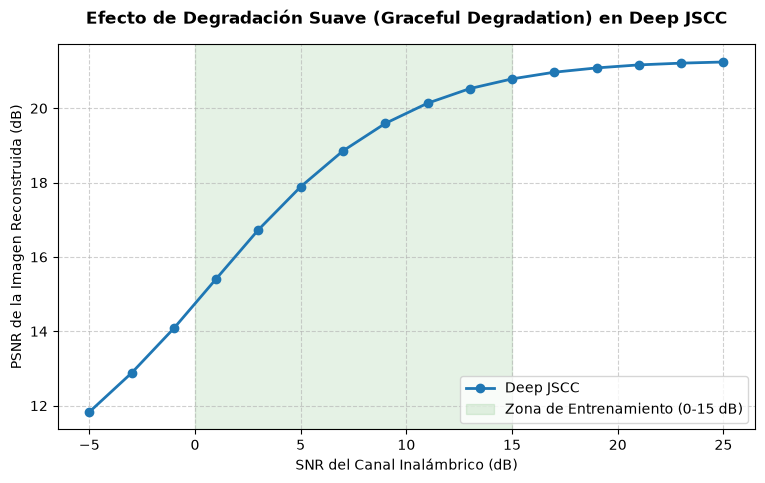

In [48]:
#-----------------------------------------------------------------------------------------------------------------------+
#Graficar la urva de PSNR (Peak Signal-to-Noise Ratio) vs. SNR del canal para demostrar el efecto de "degradación suave"
#-----------------------------------------------------------------------------------------------------------------------+
psnr_por_snr = []  
snr_test_range = np.arange(-5, 26, 2)                                   # Se define el rango de SNR para evaluar (desde canales muy ruidosos hasta limpios)
print("Evaluando el modelo en el rango de SNR especificado...")
with torch.no_grad():

    for snr_val in snr_test_range:
        mse_acumulado = 0.0
        total_images = 0

        for images, _ in test_loader:
            images = images.to(device)    
            outputs = model(images, snr_val)                                    # Se avalua un batch de imágenes
                  
            loss = nn.functional.mse_loss(outputs, images, reduction='sum')     # Se calcula el MSE del batch
            mse_acumulado += loss.item()                   
            total_images += images.numel()                                      # Contar el número total de píxeles/elementos procesados para promediar correctamente
                       
        mse_average = mse_acumulado / total_images                              # MSE promedio de todo el dataset de prueba para este SNR
            
            # Calcular PSNR (Dado que el rango de los píxeles con Sigmoid es, MAX_I = 1.0)
        if mse_average > 0:
            psnr = 10 * np.log10(1.0 / mse_average)
        else:
            psnr = float('inf') # Caso ideal sin error
                
        psnr_por_snr.append(psnr)
        print(f"SNR: {snr_val:2d} dB -> PSNR Promedio: {psnr:.2f} dB")


#Generación de la gráfica

# Configuración y renderizado de la gráfica de Degradación Suave
plt.figure(figsize=(9, 5))
plt.plot(snr_test_range, psnr_por_snr, marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Deep JSCC')
plt.title('Efecto de Degradación Suave (Graceful Degradation) en Deep JSCC', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('SNR del Canal Inalámbrico (dB)', fontsize=10)
plt.ylabel('PSNR de la Imagen Reconstruida (dB)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvspan(0, 15, color='green', alpha=0.1, label='Zona de Entrenamiento (0-15 dB)')
plt.legend(loc='lower right')
plt.show()